# ✂️ Lab 2 — Chunking Strategies

## Why Chunking Matters?

Before storing text in a vector DB, we need to split it into **chunks**.
The chunking strategy directly affects RAG quality:

```
Too large  → noisy context, LLM gets confused
Too small  → missing context, incomplete answers
Just right → relevant, focused, accurate retrieval
```

## 4 Strategies We'll Compare

| Strategy | How it works |
|---|---|
| **1. Fixed-size** | Split every N characters with overlap |
| **2. Recursive** | Split by paragraphs → sentences → words |
| **3. Sentence-level** | Split on sentence boundaries (NLTK) |
| **4. Semantic** | Group sentences by meaning similarity |

## 1️⃣ Setup

In [1]:
import fitz  # pymupdf
import nltk
import numpy as np
import pandas as pd
import ollama
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

PDF_PATH = 'data/medical_book.pdf'
print('✅ Setup done')

✅ Setup done


## 2️⃣ Extract Text from PDF

In [2]:
def extract_pages(pdf_path: str, max_pages: int = 30) -> list[dict]:
    """Extract text page by page from PDF."""
    doc   = fitz.open(pdf_path)
    pages = []
    for i, page in enumerate(doc):
        if i >= max_pages:
            break
        text = page.get_text().strip()
        if text:
            pages.append({'page': i + 1, 'text': text})
    doc.close()
    return pages

pages    = extract_pages(PDF_PATH, max_pages=30)
full_text = ' '.join([p['text'] for p in pages])

print(f'✅ Extracted {len(pages)} pages')
print(f'📝 Total characters: {len(full_text):,}')

✅ Extracted 28 pages
📝 Total characters: 54,814


---
## Strategy 1 — Fixed-Size Chunking

Split text into chunks of **fixed character size** with **overlap** to preserve context at boundaries.

```
|----chunk1----|                |
          |----chunk2----|      |
                    |----chunk3-|
          ↑overlap↑
```

In [3]:
def fixed_size_chunks(text: str, chunk_size: int = 300, overlap: int = 50) -> list[dict]:
    """
    Split text into fixed-size chunks with overlap.
    Args:
        text       : full text string
        chunk_size : max characters per chunk
        overlap    : characters shared between consecutive chunks
    """
    chunks = []
    start  = 0
    idx    = 0
    while start < len(text):
        end  = start + chunk_size
        chunk = text[start:end].strip()
        if chunk:
            chunks.append({'chunk_id': idx, 'text': chunk, 'strategy': 'fixed'})
            idx += 1
        start += chunk_size - overlap
    return chunks

fixed_chunks = fixed_size_chunks(full_text, chunk_size=300, overlap=50)
print(f'✅ Fixed-size: {len(fixed_chunks)} chunks')
print(f'   Avg length: {np.mean([len(c["text"]) for c in fixed_chunks]):.0f} chars')
print(f'\n📄 Sample chunk:')
print(fixed_chunks[5]['text'])

✅ Fixed-size: 220 chunks
   Avg length: 299 chars

📄 Sample chunk:
atologie-Urgences Mains, Hôpital Pierre Paul RIQUET, 
CHU de Toulouse, Université Paul SABATIER.
Prof. Michel CHAMMAS
Professeur des Universités-Praticien Hospitalier, Service de Chirurgie 
de la Main et du Membre Supérieur-Chirurgie des Nerfs Périphériques, 
Hôpital LAPEYRONNIE, CHU de MONTPELLIER,


---
## Strategy 2 — Recursive Character Splitting

Split by hierarchy: **paragraphs → sentences → words**.
Tries to keep natural text boundaries first.

In [4]:
def recursive_chunks(text: str, chunk_size: int = 300, overlap: int = 50) -> list[dict]:
    """
    Recursively split by: paragraphs → newlines → sentences → words.
    Falls back to smaller separators if chunk is still too large.
    """
    separators = ['\n\n', '\n', '. ', ' ']

    def split_text(text, separators):
        if not separators or len(text) <= chunk_size:
            return [text] if text.strip() else []
        sep    = separators[0]
        splits = text.split(sep)
        chunks = []
        current = ''
        for split in splits:
            if len(current) + len(split) + len(sep) <= chunk_size:
                current += split + sep
            else:
                if current.strip():
                    chunks.append(current.strip())
                if len(split) > chunk_size:
                    chunks.extend(split_text(split, separators[1:]))
                else:
                    current = split + sep
        if current.strip():
            chunks.append(current.strip())
        return chunks

    raw = split_text(text, separators)
    return [{'chunk_id': i, 'text': c, 'strategy': 'recursive'} for i, c in enumerate(raw)]

recursive_chunks_list = recursive_chunks(full_text, chunk_size=300, overlap=50)
print(f'✅ Recursive: {len(recursive_chunks_list)} chunks')
print(f'   Avg length: {np.mean([len(c["text"]) for c in recursive_chunks_list]):.0f} chars')
print(f'\n📄 Sample chunk:')
print(recursive_chunks_list[5]['text'])

✅ Recursive: 209 chunks
   Avg length: 261 chars

📄 Sample chunk:
Professeur des Universités-Praticien Hospitalier, Service de Chirurgie 
de la Main et du Membre Supérieur-Chirurgie des Nerfs Périphériques, 
Hôpital LAPEYRONNIE, CHU de MONTPELLIER, UFR Médecine 
Montpellier-Nîmes.
Prof. Benoit de BILLY
 
Prof. Philippe CHIRON


---
## Strategy 3 — Sentence-Level Chunking

Use **NLTK** to detect sentence boundaries, then group N sentences per chunk.

In [5]:
from nltk.tokenize import sent_tokenize

def sentence_chunks(text: str, sentences_per_chunk: int = 4, overlap: int = 1) -> list[dict]:
    """
    Split text into chunks of N sentences with sentence-level overlap.
    Args:
        text                : full text
        sentences_per_chunk : number of sentences per chunk
        overlap             : number of sentences shared between chunks
    """
    sentences = sent_tokenize(text)
    chunks    = []
    idx       = 0
    i         = 0
    while i < len(sentences):
        chunk = ' '.join(sentences[i:i + sentences_per_chunk])
        if chunk.strip():
            chunks.append({'chunk_id': idx, 'text': chunk.strip(), 'strategy': 'sentence'})
            idx += 1
        i += sentences_per_chunk - overlap
    return chunks

sentence_chunks_list = sentence_chunks(full_text, sentences_per_chunk=4, overlap=1)
print(f'✅ Sentence-level: {len(sentence_chunks_list)} chunks')
print(f'   Avg length: {np.mean([len(c["text"]) for c in sentence_chunks_list]):.0f} chars')
print(f'\n📄 Sample chunk:')
print(sentence_chunks_list[5]['text'])

✅ Sentence-level: 172 chunks
   Avg length: 420 chars

📄 Sample chunk:
Dr. Cécile NÉROT
Praticien Hospitalier, Service d’Orthopédie-Traumatologie, Hôpital Maison 
Blanche, CHU de REIMS, Université de Champagne-Ardennes. Prof. Laurent OBERT
Professeur des Universités-Praticien Hospitalier, Service d’Orthopédie-
Traumatologie, de Chirurgie Plastique et Reconstructrice et Assistance 
Main, Hôpital Jean Minjoz, CHU BESANCON, Université de Franche-
Comté 1. Prof. Jean Marc VITAL
Professeur des Universités-Praticien Hospitalier, Service d’Orthopédie-
Traumatologie, Hôpital Tripode, CHU de BORDEAUX, Université 
BORDEAUX. Prof. Adeline RUYSSEN-WITRAND
Professeur des Universités-Praticien Hospitalier, Service de Rhumatologie, 
Hôpital Pierre Paul RIQUET, CHU de Toulouse, Université Paul SABATIER.


---
## Strategy 4 — Semantic Chunking

Group sentences that are **semantically similar** together.
Split when the meaning changes significantly.

```
Sentence 1 ─┐
Sentence 2  ├─ high similarity → same chunk
Sentence 3 ─┘
Sentence 4 ─┐
Sentence 5  ├─ topic shift → new chunk
```

In [6]:
def embed(text: str) -> np.ndarray:
    response = ollama.embeddings(model='nomic-embed-text', prompt=text)
    return np.array(response['embedding'])

def semantic_chunks(text: str, threshold: float = 0.75, max_sentences: int = 6) -> list[dict]:
    """
    Group sentences into chunks based on semantic similarity.
    Start a new chunk when similarity drops below threshold.
    Args:
        text          : full text
        threshold     : cosine similarity threshold to split
        max_sentences : max sentences per chunk
    """
    sentences = sent_tokenize(text)
    # Limit for speed during demo
    sentences = sentences[:100]

    print(f'  Embedding {len(sentences)} sentences...')
    embeddings = np.array([embed(s) for s in sentences])

    chunks      = []
    current     = [sentences[0]]
    current_emb = [embeddings[0]]
    idx         = 0

    for i in range(1, len(sentences)):
        avg_emb = np.mean(current_emb, axis=0)
        sim     = cosine_similarity([embeddings[i]], [avg_emb])[0][0]

        if sim >= threshold and len(current) < max_sentences:
            current.append(sentences[i])
            current_emb.append(embeddings[i])
        else:
            chunks.append({'chunk_id': idx, 'text': ' '.join(current), 'strategy': 'semantic'})
            idx    += 1
            current     = [sentences[i]]
            current_emb = [embeddings[i]]

    if current:
        chunks.append({'chunk_id': idx, 'text': ' '.join(current), 'strategy': 'semantic'})

    return chunks

print('⏳ Running semantic chunking (may take ~1 min)...')
semantic_chunks_list = semantic_chunks(full_text, threshold=0.75)
print(f'✅ Semantic: {len(semantic_chunks_list)} chunks')
print(f'   Avg length: {np.mean([len(c["text"]) for c in semantic_chunks_list]):.0f} chars')
print(f'\n📄 Sample chunk:')
print(semantic_chunks_list[5]['text'])

⏳ Running semantic chunking (may take ~1 min)...
  Embedding 100 sentences...
✅ Semantic: 77 chunks
   Avg length: 163 chars

📄 Sample chunk:
Dr. Etienne CAVAIGNAC
Maître de Conférences des Universités – Praticien Hospitalier, Département 
d’Orthopédie-Traumatologie-Urgences Mains, Hôpital Pierre Paul RIQUET, 
CHU de Toulouse, Université Paul SABATIER.


---
## 📊 Compare All 4 Strategies

In [7]:
all_strategies = {
    'Fixed-Size':  fixed_chunks,
    'Recursive':   recursive_chunks_list,
    'Sentence':    sentence_chunks_list,
    'Semantic':    semantic_chunks_list,
}

# Summary table
rows = []
for name, chunks in all_strategies.items():
    lengths = [len(c['text']) for c in chunks]
    rows.append({
        'Strategy':    name,
        'Num Chunks':  len(chunks),
        'Avg Length':  f'{np.mean(lengths):.0f}',
        'Min Length':  min(lengths),
        'Max Length':  max(lengths),
        'Std Dev':     f'{np.std(lengths):.0f}',
    })

df = pd.DataFrame(rows)
print('📊 Chunking Strategies Comparison')
print('=' * 60)
print(df.to_string(index=False))

📊 Chunking Strategies Comparison
  Strategy  Num Chunks Avg Length  Min Length  Max Length Std Dev
Fixed-Size         220        299          64         300      16
 Recursive         209        261         182         299      25
  Sentence         172        420          78        1100     191
  Semantic          77        163           2        1399     233


/tmp/ipykernel_36191/3996041956.py:17: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/abdelalim/projects/stages/RAG/medical-rag-advanced/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


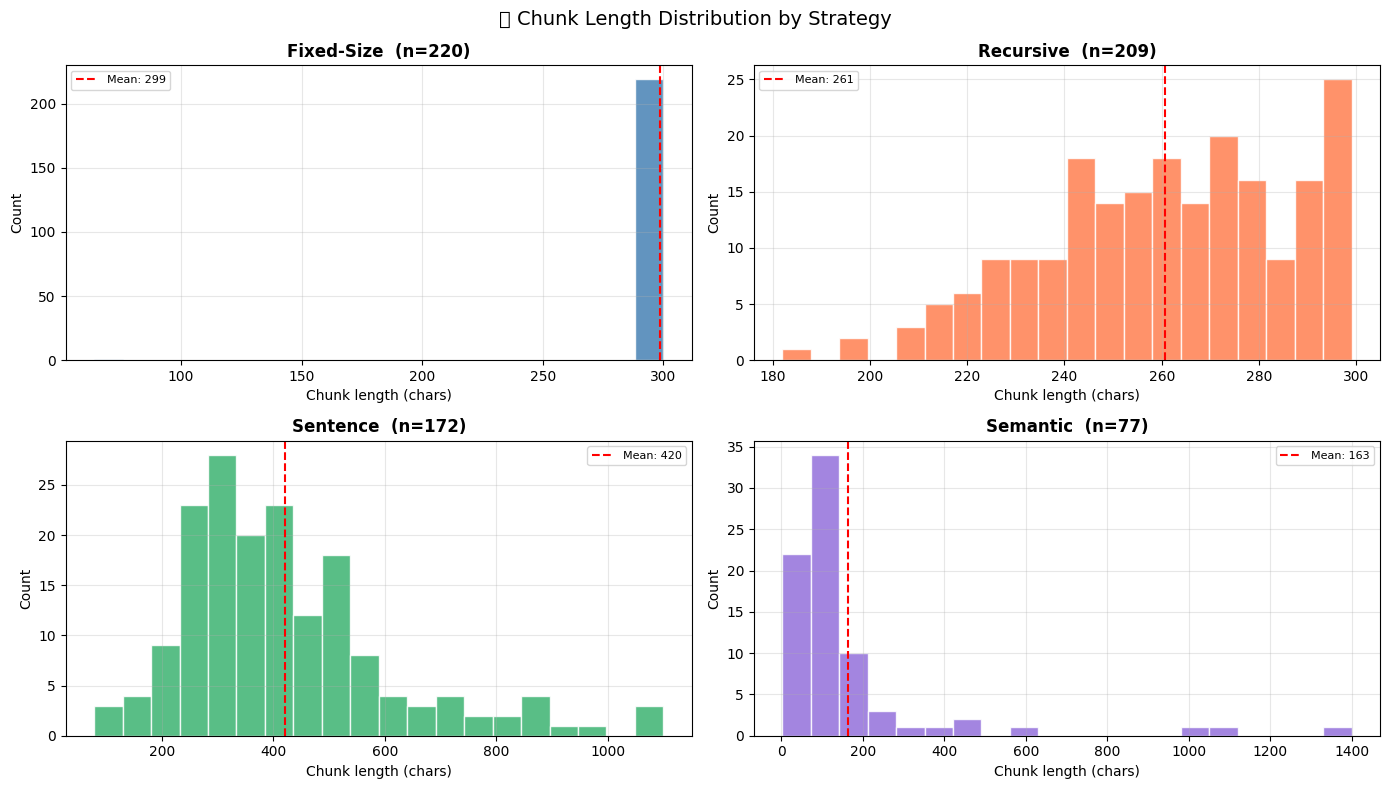

In [8]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('📊 Chunk Length Distribution by Strategy', fontsize=14)

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for ax, (name, chunks), color in zip(axes.flat, all_strategies.items(), colors):
    lengths = [len(c['text']) for c in chunks]
    ax.hist(lengths, bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{name}  (n={len(chunks)})', fontweight='bold')
    ax.set_xlabel('Chunk length (chars)')
    ax.set_ylabel('Count')
    ax.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.0f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🏆 Which Strategy is Best?

Test each strategy on a sample medical query.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

def find_best_chunk(query: str, chunks: list[dict], top_k: int = 1) -> list[dict]:
    """Find most relevant chunk for a query using cosine similarity."""
    query_emb   = embed(query)
    chunk_texts = [c['text'] for c in chunks]
    chunk_embs  = np.array([embed(t) for t in chunk_texts[:50]])  # limit for speed
    scores      = cosine_similarity([query_emb], chunk_embs)[0]
    top_idx     = np.argsort(-scores)[:top_k]
    return [(chunks[i], scores[i]) for i in top_idx]

query = 'What diseases affect the skin?'
print(f'🔍 Query: "{query}"')
print('=' * 60)

for name, chunks in all_strategies.items():
    best = find_best_chunk(query, chunks)[0]
    print(f'\n📌 {name} (score: {best[1]:.4f})')
    print(f'   {best[0]["text"][:200]}...')

🔍 Query: "What diseases affect the skin?"

📌 Fixed-Size (score: 0.5624)
   t ne sont responsables d’aucune symptomatologie 
fonctionnelle.
¢
La luxation congénitale de hanche (LCH), et les déformations du rachis (Scoliose, Cyphose) consti-
tuent, un vrai problème de santé pu...

📌 Recursive (score: 0.5454)
   Connaître les déformations du rachis de l’enfant et de l’adolescent, les modalités de 
leur dépistage, et leurs conséquences.
I. 
POUR BIEN COMPRENDRE
¢
La majorité des anomalies orthopédiques de l’en...

📌 Sentence (score: 0.5250)
   ¢
La luxation congénitale de hanche (LCH), et les déformations du rachis (Scoliose, Cyphose) consti-
tuent, un vrai problème de santé publique. Leur diagnostic repose sur une stratégie de dépistage 
c...

📌 Semantic (score: 0.5532)
   ¢
La luxation congénitale de hanche (LCH), et les déformations du rachis (Scoliose, Cyphose) consti-
tuent, un vrai problème de santé publique....


## ✅ Lab 2 Summary

| Strategy | Best For | Weakness |
|---|---|---|
| **Fixed-size** | Simple, fast | May cut mid-sentence |
| **Recursive** | Natural boundaries | May miss semantic shifts |
| **Sentence** | Clean splits | Chunks vary in size |
| **Semantic** | Best quality | Slowest (needs embedding) |

### 🏆 Recommendation
For a **medical book RAG** → **Sentence-level** or **Semantic** chunking gives the best results because medical content has clear sentence boundaries and topic shifts.

➡️ **Next: Lab 3 — Full RAG Pipeline**